In [1]:
import os, shutil, numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, classification_report
from sklearn.preprocessing import label_binarize
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


extracting the images from the rar

In [6]:
!pip install unrar-free
!apt-get install unrar
!mkdir -p raw_images
!unrar x "10973_2021_10903_MOESM2_ESM.rar" raw_images/

ERROR: Could not find a version that satisfies the requirement unrar-free (from versions: none)
ERROR: No matching distribution found for unrar-free
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from 10973_2021_10903_MOESM2_ESM.rar

Extracting  raw_images/S1_Raw_Photographs_Full_Study/Ethanol_Full_0001.JPG       0%  OK 
Extracting  raw_images/S1_Raw_Photographs_Full_Study/Ethanol_Full_0002.JPG       0%  OK 
Extracting  raw_images/S1_Raw_Photographs_Full_Study/Ethanol_Full_0003.JPG       0%  OK 
Extracting  raw_images/S1_Raw_Photographs_Full_Study/Ethanol_Full_0004.JPG       0%  OK 
Extracting  raw_images/S1_Raw_Photographs_Full_Study/Ethanol_Full_0005.JPG       0%  OK 
Extracting  raw_i

In [7]:
import os, shutil, glob

for f in glob.glob("raw_images/**/*.*", recursive=True):
    shutil.move(f, "raw_images/" + os.path.basename(f))

DATA_DIR = "data"
for c in ["ethanol", "pentane", "propanol"]:
    os.makedirs(DATA_DIR + "/" + c, exist_ok=True)

for f in os.listdir("raw_images"):
    for c in ["ethanol", "pentane", "propanol"]:
        if c in f.lower():
            shutil.copy2("raw_images/" + f, DATA_DIR + "/" + c + "/" + f)
            break

for c in ["ethanol", "pentane", "propanol"]:
    print(c, ":", len(os.listdir(DATA_DIR + "/" + c)))

ethanol : 1000
pentane : 1000
propanol : 1000


loafding the train and test

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

dataset = datasets.ImageFolder("data", transform=transform)
train_set, val_set, test_set = random_split(dataset, [2100, 450, 450])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)

print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

Train: 2100 Val: 450 Test: 450


transfer learning model

In [9]:
model = models.resnet34(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 74.2MB/s]


In [18]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, count = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        count += y.size(0)
    return total_loss / count, correct / count

def evaluate(model, loader):
    model.eval()
    total_loss, correct, count = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            count += y.size(0)
    return total_loss / count, correct / count

In [11]:
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

for epoch in range(5):
    tl, ta = train_epoch(model, train_loader, optimizer)
    vl, va = evaluate(model, val_loader)
    train_losses.append(tl)
    val_losses.append(vl)
    train_accs.append(ta)
    val_accs.append(va)
    print("Epoch", epoch+1, " Train Loss:", round(tl,4), "Acc:", round(ta,4),
          " Val Loss:", round(vl,4), "Acc:", round(va,4))

Epoch 1  Train Loss: 1.1396 Acc: 0.3648  Val Loss: 1.0018 Acc: 0.5067
Epoch 2  Train Loss: 0.9298 Acc: 0.5857  Val Loss: 0.8348 Acc: 0.6689
Epoch 3  Train Loss: 0.7785 Acc: 0.7395  Val Loss: 0.7253 Acc: 0.7644
Epoch 4  Train Loss: 0.6988 Acc: 0.7824  Val Loss: 0.6289 Acc: 0.8533
Epoch 5  Train Loss: 0.6119 Acc: 0.8319  Val Loss: 0.5907 Acc: 0.8444


In [12]:
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

for epoch in range(5):
    tl, ta = train_epoch(model, train_loader, optimizer)
    vl, va = evaluate(model, val_loader)
    train_losses.append(tl)
    val_losses.append(vl)
    train_accs.append(ta)
    val_accs.append(va)
    print("Epoch", epoch+6, " Train Loss:", round(tl,4), "Acc:", round(ta,4),
          " Val Loss:", round(vl,4), "Acc:", round(va,4))

Epoch 6  Train Loss: 0.2457 Acc: 0.9338  Val Loss: 0.1198 Acc: 0.9489
Epoch 7  Train Loss: 0.1076 Acc: 0.9624  Val Loss: 0.0605 Acc: 0.9867
Epoch 8  Train Loss: 0.0815 Acc: 0.9752  Val Loss: 0.0417 Acc: 0.9911
Epoch 9  Train Loss: 0.0566 Acc: 0.98  Val Loss: 0.0337 Acc: 0.9933
Epoch 10  Train Loss: 0.0443 Acc: 0.9867  Val Loss: 0.0361 Acc: 0.9867


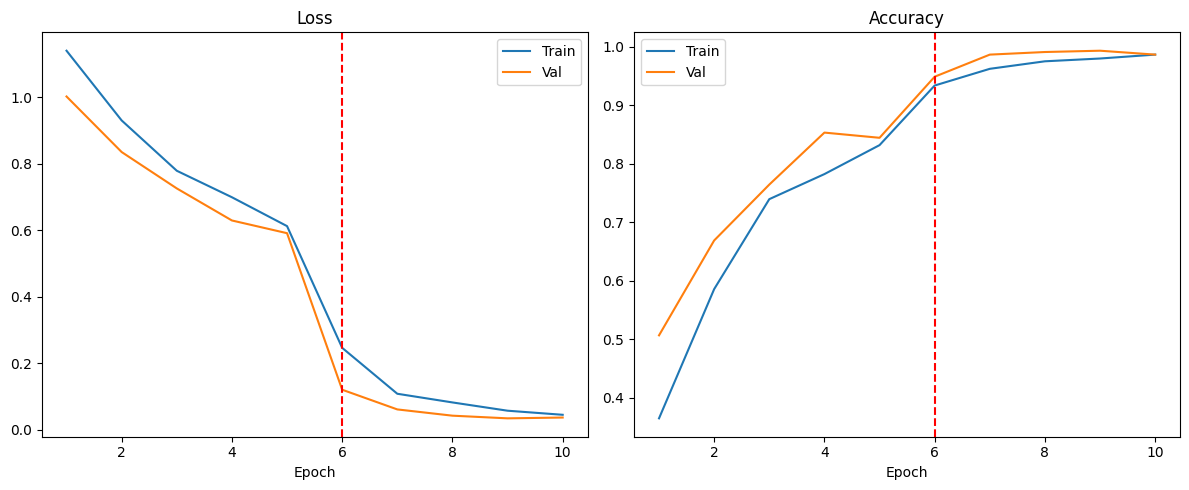

In [19]:
epochs = range(1, 11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epochs, train_losses, label="Train")
ax1.plot(epochs, val_losses, label="Val")
ax1.axvline(6, color="red", ls="--")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs, train_accs, label="Train")
ax2.plot(epochs, val_accs, label="Val")
ax2.axvline(6, color="red", ls="--")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

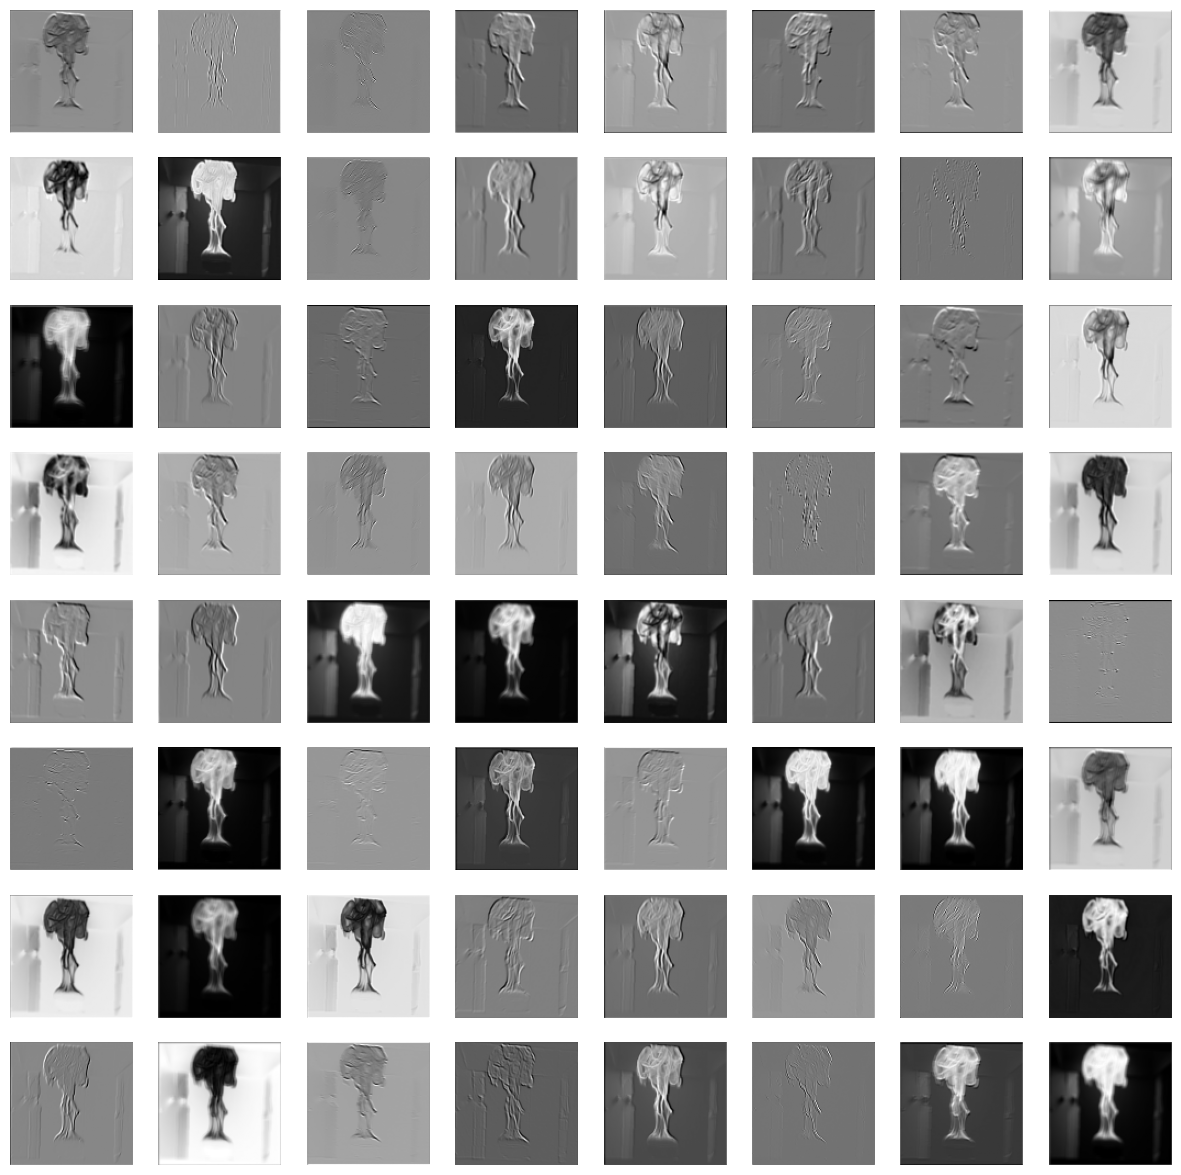

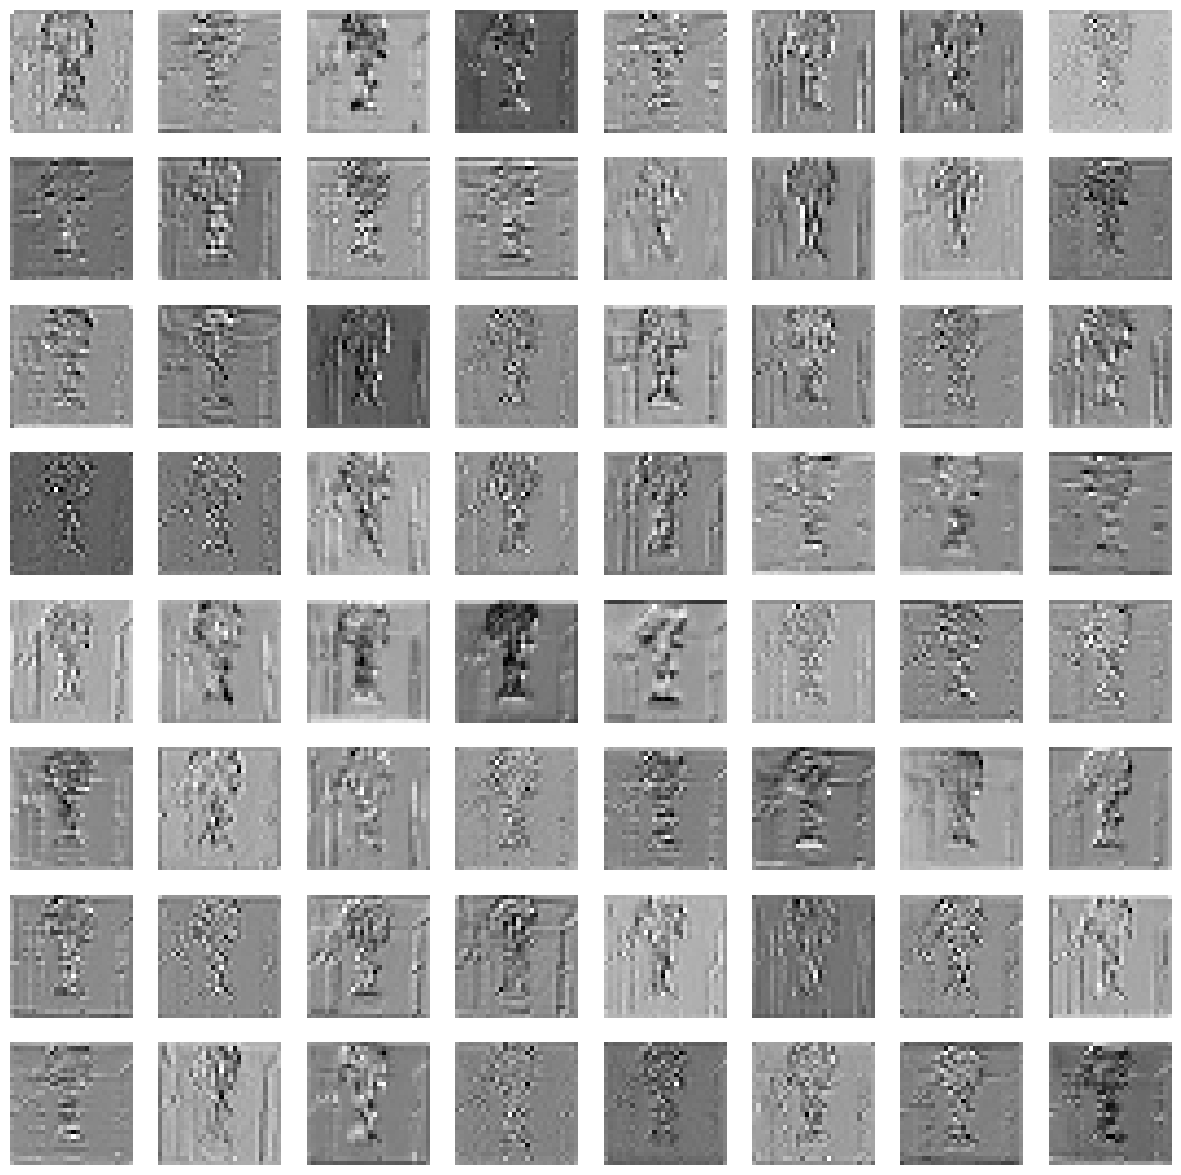

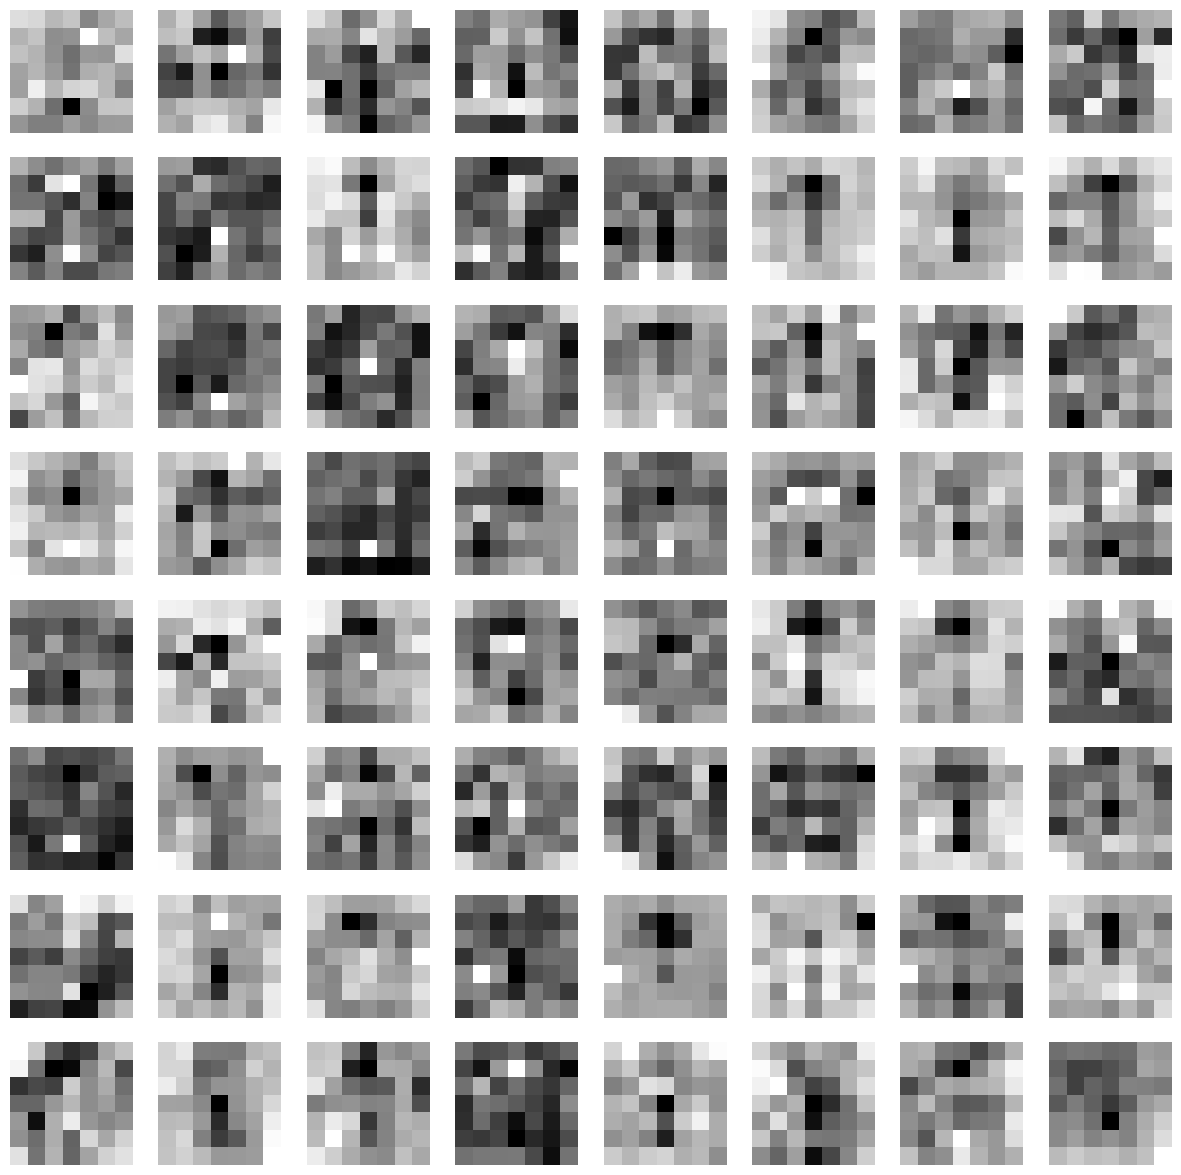

In [23]:
def visualize_hook(module, input, output):
    n = min(output.size(1), 64)
    plt.figure(figsize=(15, 15))
    for i in range(n):
        plt.subplot(8, 8, i + 1)
        plt.imshow(output[0, i].detach().cpu().numpy(), cmap="gray")
        plt.axis("off")
    plt.show()

image, _ = test_set[0]
image = image.unsqueeze(0).to(device)

model.eval()

hook = model.conv1.register_forward_hook(visualize_hook)
with torch.no_grad():
    model(image)
hook.remove()

hook = model.layer2[0].conv1.register_forward_hook(visualize_hook)
with torch.no_grad():
    model(image)
hook.remove()

hook = model.layer4[0].conv1.register_forward_hook(visualize_hook)
with torch.no_grad():
    model(image)
hook.remove()

In [15]:
def get_predictions(m):
    m.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for x, y in test_loader:
            out = m(x.to(device))
            preds.append(out.argmax(1).cpu())
            labels.append(y)
            probs.append(torch.softmax(out, 1).cpu())
    return torch.cat(preds).numpy(), torch.cat(labels).numpy(), torch.cat(probs).numpy()

y_pred, y_true, y_prob = get_predictions(model)
print("Fine-tuned Accuracy:", round((y_pred == y_true).mean(), 4))
print(classification_report(y_true, y_pred, target_names=dataset.classes))

baseline = models.resnet34(pretrained=True)
baseline.fc = nn.Linear(512, 3)
baseline = baseline.to(device)
y_base, _, _ = get_predictions(baseline)
print("Baseline Accuracy:", round((y_base == y_true).mean(), 4))

Fine-tuned Accuracy: 0.9822
              precision    recall  f1-score   support

     ethanol       1.00      0.99      0.99       162
     pentane       1.00      0.96      0.98       142
    propanol       0.95      1.00      0.97       146

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Baseline Accuracy: 0.4


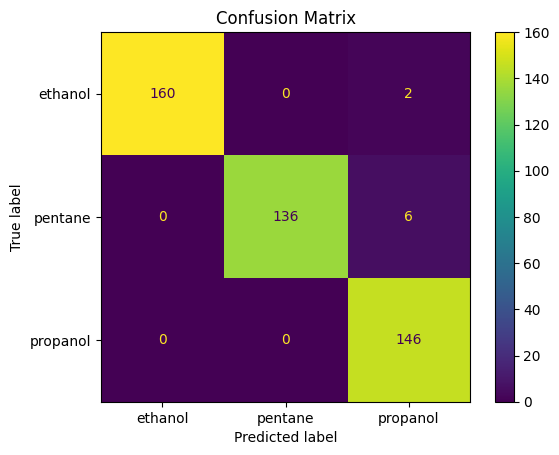

In [16]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=dataset.classes).plot(ax=ax)
ax.set_title("Confusion Matrix")
plt.show()

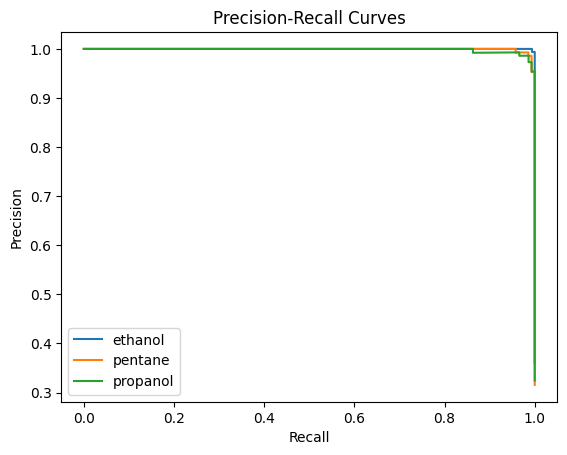

In [17]:
y_bin = label_binarize(y_true, classes=[0, 1, 2])

for i, name in enumerate(dataset.classes):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
    plt.plot(rec, prec, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()